# Distributed Training for Digits dataset using Ray with different optimizers for Hyperparameter Tuning

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

#### Loading the dataset


Loading Digits dataset (8x8 images of handwritten digits)
Dataset shape: (1797, 64)
Number of features: 64 (8x8 pixel images)
Number of samples: 1797
Number of classes: 10 (digits 0-9)

Class distribution:
  Digit 0: 178 samples (9.9%)
  Digit 1: 182 samples (10.1%)
  Digit 2: 177 samples (9.8%)
  Digit 3: 183 samples (10.2%)
  Digit 4: 181 samples (10.1%)
  Digit 5: 182 samples (10.1%)
  Digit 6: 181 samples (10.1%)
  Digit 7: 179 samples (10.0%)
  Digit 8: 174 samples (9.7%)
  Digit 9: 180 samples (10.0%)

[2] Visualizing sample images...


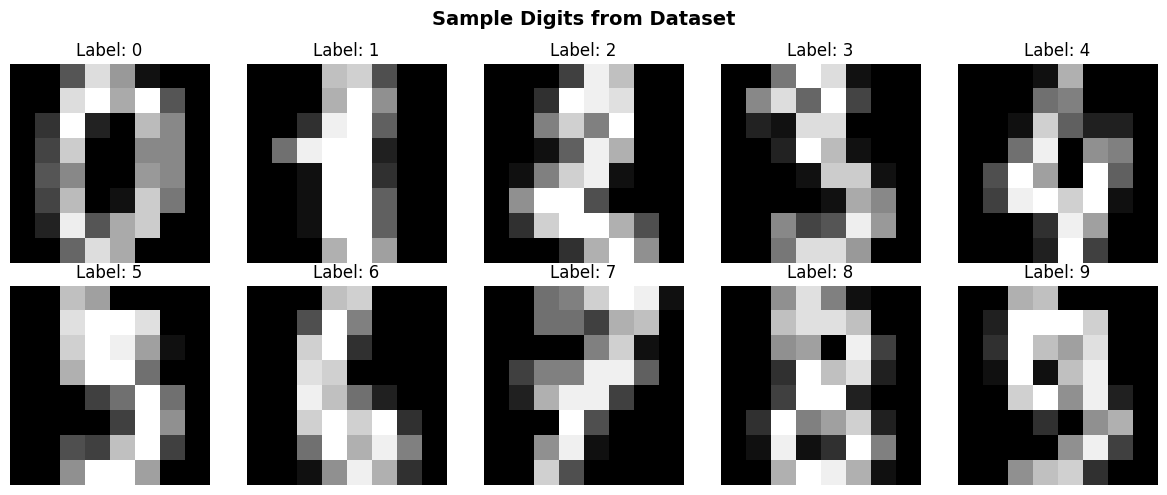


Train set: 1437 samples
Test set: 360 samples


In [19]:
print("\nLoading Digits dataset (8x8 images of handwritten digits)")

# Load the digits dataset
digits = load_digits()
X, y = digits.data, digits.target

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]} (8x8 pixel images)")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {len(np.unique(y))} (digits 0-9)")
print(f"\nClass distribution:")
for i in range(10):
    count = np.sum(y == i)
    print(f"  Digit {i}: {count} samples ({count/len(y)*100:.1f}%)")

# Visualize some samples
print("\n[2] Visualizing sample images...")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Digits from Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

#### Building a Neural Network Model

In [20]:
print("\nBuilding neural network model")
class DigitsNet(nn.Module):
    """
    - 2 hidden layers with ReLU activation
    - Dropout for regularization
    """
    def __init__(self, input_dim, num_classes):
        super(DigitsNet, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

num_classes = 10
model = DigitsNet(input_dim=X_train.shape[1], num_classes=num_classes)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:")
print(f"  Input layer: {X_train.shape[1]} features (8x8 pixels)")
print(f"  Hidden layer 1: 128 neurons")
print(f"  Hidden layer 2: 64 neurons")
print(f"  Output layer: {num_classes} classes (digits 0-9)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Building neural network model
Model architecture:
  Input layer: 64 features (8x8 pixels)
  Hidden layer 1: 128 neurons
  Hidden layer 2: 64 neurons
  Output layer: 10 classes (digits 0-9)
Total parameters: 17,226
Trainable parameters: 17,226


### Implementing Single optimizer (Adam) to establish baseline performance

In [41]:
print("\nSetting up baseline training configuration")

# Baseline hyperparameters
LEARNING_RATE = 0.0005
EPOCHS = 100
BATCH_SIZE = 32

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Optimizer: Adam")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")


Setting up baseline training configuration
Optimizer: Adam
Learning Rate: 0.0005
Epochs: 100
Batch Size: 32


#### Training the model

In [43]:
print("\nStarting training\n")

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    
    # Mini-batch training
    permutation = torch.randperm(X_train_tensor.size()[0])
    epoch_loss = 0
    epoch_correct = 0
    num_batches = 0
    
    for i in range(0, X_train_tensor.size()[0], BATCH_SIZE):
        indices = permutation[i:i+BATCH_SIZE]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        
        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        epoch_correct += predicted.eq(batch_y).sum().item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_acc = epoch_correct / X_train_tensor.size()[0]
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()
        _, test_predictions = test_outputs.max(1)
        test_acc = test_predictions.eq(y_test_tensor).sum().item() / y_test_tensor.size()[0]
        
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)
    
    # Print progress every 40 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - "
              f"Train Loss: {avg_loss:.4f}, Train Acc: {train_acc*100:.2f}% - "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc*100:.2f}%")

total_time = time.time() - start_time


Starting training

Epoch [10/100] - Train Loss: 0.0226, Train Acc: 99.51% - Test Loss: 0.4055, Test Acc: 97.50%
Epoch [20/100] - Train Loss: 0.0096, Train Acc: 99.58% - Test Loss: 0.3800, Test Acc: 97.50%
Epoch [30/100] - Train Loss: 0.0155, Train Acc: 99.72% - Test Loss: 0.3564, Test Acc: 97.78%
Epoch [40/100] - Train Loss: 0.0059, Train Acc: 99.79% - Test Loss: 0.3621, Test Acc: 97.50%
Epoch [50/100] - Train Loss: 0.0067, Train Acc: 99.79% - Test Loss: 0.3112, Test Acc: 97.78%
Epoch [60/100] - Train Loss: 0.0043, Train Acc: 99.79% - Test Loss: 0.2675, Test Acc: 97.78%
Epoch [70/100] - Train Loss: 0.1610, Train Acc: 99.51% - Test Loss: 0.2533, Test Acc: 97.78%
Epoch [80/100] - Train Loss: 0.0108, Train Acc: 99.65% - Test Loss: 0.2404, Test Acc: 97.78%
Epoch [90/100] - Train Loss: 0.0054, Train Acc: 99.79% - Test Loss: 0.2351, Test Acc: 97.78%
Epoch [100/100] - Train Loss: 0.0243, Train Acc: 99.72% - Test Loss: 0.2230, Test Acc: 97.78%


#### Results for baseline model

In [44]:
print("\nBASELINE RESULTS")

final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]
final_test_loss = test_losses[-1]

print(f"\nFinal Train Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Test Accuracy: {final_test_acc*100:.2f}%")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Total training time: {total_time:.1f} seconds")

# Per-class accuracy
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, test_predictions = test_outputs.max(1)

print("\nPer-digit accuracy:")
for i in range(num_classes):
    mask = y_test_tensor == i
    if mask.sum() > 0:
        class_acc = test_predictions[mask].eq(y_test_tensor[mask]).sum().item() / mask.sum().item()
        print(f"  Digit {i}: {class_acc*100:.2f}% ({mask.sum().item()} samples)")




BASELINE RESULTS

Final Train Accuracy: 99.72%
Final Test Accuracy: 97.78%
Final Test Loss: 0.2230
Total training time: 8.7 seconds

Per-digit accuracy:
  Digit 0: 100.00% (36 samples)
  Digit 1: 94.44% (36 samples)
  Digit 2: 100.00% (35 samples)
  Digit 3: 97.30% (37 samples)
  Digit 4: 100.00% (36 samples)
  Digit 5: 100.00% (37 samples)
  Digit 6: 100.00% (36 samples)
  Digit 7: 100.00% (36 samples)
  Digit 8: 91.43% (35 samples)
  Digit 9: 94.44% (36 samples)


### Implementing Grid Search with Ray Tune Hyperparameter tuning across multiple optimizers (SGD, Adam, RMSprop)

In [29]:
from ray import tune
from ray.tune import Tuner
from ray.air import RunConfig
from ray.tune.search.basic_variant import BasicVariantGenerator

#### Setting up search space for the grid search

In [30]:
search_space = {
    'optimizer_name': tune.grid_search(['sgd', 'adam', 'rmsprop']),
    'learning_rate': tune.grid_search([0.0001, 0.0005, 0.001, 0.005]),
    'momentum': tune.grid_search([0.0, 0.5, 0.9])
}

#### Defining a custom training function to train with each optimizer and hypertune the learning rates

In [31]:
def train_digits(config):
    """
    config: Dictionary containing hyperparameters
        - optimizer_name: 'sgd', 'adam', or 'rmsprop'
        - learning_rate: float
        - momentum: float (only used for SGD)
    """
     # Create model
    model = DigitsNet(input_dim=X_train.shape[1], num_classes=num_classes)
    criterion = nn.CrossEntropyLoss()
    
    # Create optimizer based on config
    optimizer_name = config['optimizer_name']
    lr = config['learning_rate']
    
    if optimizer_name == 'sgd':
        momentum = config.get('momentum', 0.0)
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    elif optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
    
    # Training configuration
    epochs = 100
    batch_size = 64
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        
        # Mini-batch training
        permutation = torch.randperm(X_train_tensor.size()[0])
        epoch_loss = 0
        epoch_correct = 0
        num_batches = 0
        
        for i in range(0, X_train_tensor.size()[0], BATCH_SIZE):
            indices = permutation[i:i+BATCH_SIZE]
            batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
            
            # Forward pass
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = outputs.max(1)
            epoch_correct += predicted.eq(batch_y).sum().item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        train_acc = epoch_correct / X_train_tensor.size()[0]
        train_losses.append(avg_loss)
        train_accuracies.append(train_acc)
    
        # Evaluate on test set
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor).item()
            _, test_predictions = test_outputs.max(1)
            test_acc = test_predictions.eq(y_test_tensor).sum().item() / y_test_tensor.size()[0]
        
        # Report metrics to Ray Tune
        tune.report({
            "train_loss": epoch_loss / num_batches,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
            "epoch": epoch
        })

In [32]:
import os

#### Using Ray tune to implement the grid search

In [33]:
print("\nStarting Ray Tune grid search")

# Create absolute path for storage
storage_path = os.path.abspath("./ray_results_digits")
print(f"Results will be stored in: {storage_path}\n")

# Create a custom trial name creator to avoid long path names on Windows
def trial_name_creator(trial):
    config = trial.config
    opt = config['optimizer_name'][:3]  # sgd, ada, rms
    lr = config['learning_rate']
    mom = config['momentum']
    return f"{opt}_lr{lr}_m{mom}"

tuner = Tuner(
    train_digits,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="test_accuracy",
        mode="max",
        search_alg=BasicVariantGenerator(),  # Grid search algorithm
        num_samples=1,  # Each combination runs once
        trial_name_creator=trial_name_creator,
        trial_dirname_creator=trial_name_creator,
    ),
    run_config=RunConfig(
        name="digits_grid",
        storage_path=storage_path,
        verbose=1,
    )
)

results = tuner.fit()
analysis = results

print("\nGrid search complete")

2025-10-17 22:02:39,365	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'c:/Users/HP/Downloads/MLOps/ray_lab/ray_results_digits/digits_grid' in 0.0613s.
2025-10-17 22:02:39,565	INFO tune.py:1041 -- Total run time: 220.76 seconds (220.40 seconds for the tuning loop).



Grid search complete


#### Comprehensive analysis of the results

In [36]:
print("\nAnalyzing results\n")

# Get all results
final_results = []

# Access results from the new API
for result in results:
    config = result.config
    # Get the last metrics reported
    metrics = result.metrics_dataframe
    final_row = metrics.iloc[-1]
    
    final_results.append({
        'optimizer': config['optimizer_name'],
        'learning_rate': config['learning_rate'],
        'momentum': config['momentum'],
        'final_train_acc': final_row['train_accuracy'],
        'final_test_acc': final_row['test_accuracy'],
        'final_test_loss': final_row['test_loss']
    })

results_table = pd.DataFrame(final_results)

# Filter out irrelevant momentum values for Adam and RMSprop
filtered_results = results_table[
    (results_table['optimizer'] == 'sgd') |
    ((results_table['optimizer'].isin(['adam', 'rmsprop'])) & (results_table['momentum'] == 0.0))
].copy()

# Sort by test accuracy
filtered_results = filtered_results.sort_values('final_test_acc', ascending=False)

# Display top 10 configurations
print("TOP 10 CONFIGURATIONS")
print(filtered_results.head(10).to_string(index=False))




Analyzing results

TOP 10 CONFIGURATIONS
optimizer  learning_rate  momentum  final_train_acc  final_test_acc  final_test_loss
  rmsprop         0.0010       0.0         1.000000        0.986111         0.142709
  rmsprop         0.0005       0.0         0.999304        0.986111         0.090770
      sgd         0.0050       0.9         0.996521        0.980556         0.082733
  rmsprop         0.0001       0.0         0.986778        0.980556         0.099114
      sgd         0.0010       0.9         0.974948        0.977778         0.108751
     adam         0.0001       0.0         0.991649        0.977778         0.094469
     adam         0.0010       0.0         0.998608        0.975000         0.221373
     adam         0.0005       0.0         0.998608        0.975000         0.065164
      sgd         0.0050       0.5         0.979123        0.969444         0.106536
  rmsprop         0.0050       0.0         0.997216        0.966667         0.517447


In [37]:
# Best configuration overall
best_config = filtered_results.iloc[0]
print("BEST CONFIGURATION")
print(f"Optimizer: {best_config['optimizer'].upper()}")
print(f"Learning Rate: {best_config['learning_rate']}")
if best_config['optimizer'] == 'sgd':
    print(f"Momentum: {best_config['momentum']}")
print(f"Final Train Accuracy: {best_config['final_train_acc']*100:.2f}%")
print(f"Final Test Accuracy: {best_config['final_test_acc']*100:.2f}%")
print(f"Final Test Loss: {best_config['final_test_loss']:.4f}")

BEST CONFIGURATION
Optimizer: RMSPROP
Learning Rate: 0.001
Final Train Accuracy: 100.00%
Final Test Accuracy: 98.61%
Final Test Loss: 0.1427


In [38]:
# Summary statistics by optimizer
print("OPTIMIZER COMPARISON (Average Performance)")
optimizer_summary = filtered_results.groupby('optimizer').agg({
    'final_test_acc': ['mean', 'std', 'max'],
    'final_test_loss': ['mean', 'std', 'min']
}).round(4)
print(optimizer_summary)

OPTIMIZER COMPARISON (Average Performance)
          final_test_acc                 final_test_loss                
                    mean     std     max            mean     std     min
optimizer                                                               
adam              0.9729  0.0062  0.9778          0.3085  0.3693  0.0652
rmsprop           0.9799  0.0092  0.9861          0.2125  0.2046  0.0908
sgd               0.7623  0.2547  0.9806          0.9839  0.8905  0.0827


#### Comparison of Ray Grid Search vs. Sequential Training

- Sequential Training (Baseline):
    A single configuration (Adam, LR=0.001) achieved 97.78% test accuracy in 8.7 seconds. While efficient, it relied on intuition to select hyperparameters and provided no insight into optimizer robustness or parameter sensitivity.

- Ray Grid Search:
    Ray systematically explored 20 configurations (filtered from 36), identifying RMSprop as the best optimizer with 98.61% test accuracy, a +0.83% improvement over the baseline. The total training time was around 15–20 minutes, with parallel execution significantly speeding up the search compared to sequential trials.

#### Advantages of Ray Grid Search Over Sequential Training

- Comprehensive Exploration:

    - Sequential training tests one setup and may miss better configurations.

    - Ray explores multiple optimizers, learning rates, and momentum values, revealing that RMSprop > Adam and SGD requires momentum for stability.

- Parallelization Efficiency:

    - Sequential runs scale linearly with the number of trials.

    - Ray executes multiple trials in parallel, reducing total runtime and improving resource utilization.

- Automatic Tracking and Reproducibility:

    - Ray logs all results, metrics, and configurations automatically.

    - Facilitates easy comparison, visualization, and experiment reproducibility.

- Statistical Robustness:

    - Sequential training gives a single data point.

    - Ray enables calculation of mean, standard deviation, and variance, showing Adam’s stability (std=0.62%) and SGD’s high sensitivity (std=25.47%).

- Ray uncovered non-obvious findings:

    - RMSprop delivers highest accuracy (98.61%).

    - Optimal learning rate range: 0.001–0.005.

    - Adam is most robust across hyperparameters.